# Primary example

## Model: 24-bus

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB
import random

# Data initialization

In [2]:
# initialize relevant data
current_filepath = Path('.').resolve().parent
data_path = current_filepath / 'raw-data'

branches_df = pd.read_csv(filepath_or_buffer=data_path / 'branches.csv', skiprows=1)
buses_df = pd.read_csv(filepath_or_buffer=data_path / 'buses.csv', skiprows=1)
ptdf_df = pd.read_csv(filepath_or_buffer=data_path / 'ptdf.csv', skiprows=1)
sf_contingencies_df = pd.read_csv(filepath_or_buffer=data_path / 'sf-contingencies.csv', skiprows=1)

# Limit Generation

In [3]:
random.seed(370)
np.random.seed(370)

branches_df.loc[branches_df["Lim MVA A"] == 0, "Lim MVA A"] = [random.choice([260, 520]) for _ in range(branches_df.loc[branches_df["Lim MVA A"] == 0].shape[0])]

# Bid stack generation

In [4]:
gens = pd.read_csv(filepath_or_buffer=data_path / 'gens.csv', skiprows=1)
gens.head()

,Number of Bus,Name of Bus,ID,Status,Gen MW,Gen Mvar,Min MW,Max MW,AGC,AVR,RegBus Num,Set Volt,Min Mvar,Max Mvar,Enforce MW Limits,Part. Factor,Cost Model
0,1,1,1,Closed,35.85,180.36,0.0,1000.0,YES,YES,1,1.0,-9900.0,9900.0,YES,1000.0,NaN
1,2,2,1,Closed,67.00,0.00,0.0,1000.0,YES,YES,2,1.0,0.0,0.0,YES,1000.0,NaN
2,7,7,1,Closed,64.00,0.00,0.0,1000.0,YES,YES,7,1.0,0.0,0.0,YES,1000.0,NaN
3,13,13,1,Closed,200.00,0.00,0.0,1000.0,YES,YES,13,1.0,0.0,0.0,YES,1000.0,NaN
4,14,14,1,Closed,0.00,0.00,0.0,1000.0,YES,YES,14,1.0,0.0,0.0,YES,1000.0,NaN


## Generator Offers

In [5]:
generator_node = gens["Number of Bus"].to_numpy()
generator_min = np.zeros(generator_node.shape[0])
generator_max = np.zeros(generator_node.shape[0])
generator_cost = []

for i in range(generator_node.shape[0]):
    if random.randint(0, 1) == 0:
        generator_min[i] = random.randrange(10, 50, 10)
        generator_max[i] = max(generator_min[i] + 10, int(np.random.normal(125, 25)) * 10)
        
        # Assume non-zero min gen is only for thermal generators
        # Who have agreements to guaruntee production for reliability
        generator_cost.append(random.randrange(10, 15))
    else:
        generator_min[i] = 0
        generator_max[i] = max(generator_min[i] + 10, int(np.random.normal(125, 25)) * 10)
        # Assume renewables dont have min gen since they don't have such agreements
        # However they can effectively "guarantee" production by bidding negative prices
        # since they will always produce, and recieve subsidies for production
        # even if they clear at negative prices, they still make money from the
        # subsidies paying off (and to avoid shutdown costs)
        generator_cost.append(random.randrange(-10, 10))
generator_cost = np.array(generator_cost)

## Load Bids

In [6]:
load_buses = buses_df["Number"].to_numpy()
bus_to_idx = {bus: idx for idx, bus in enumerate(load_buses)}
nominal_demand = buses_df['Load MW'].replace([np.nan], 0).to_numpy()
load_node = buses_df['Number'].to_numpy()
load_node = load_node[nominal_demand != 0]
nominal_demand = nominal_demand[nominal_demand != 0]

In [7]:
load_node = buses_df['Number'].to_numpy()
nodal_bids = []
for bus in load_node:
    if bus in generator_node:
        continue # Typically loads dont place bids at buses with generators

    num_bids = random.randint(4, 15)
    for i in range(random.randint(10, max(20, int(np.sqrt(load_buses.shape[0]) * 2)))):
        nodal_bids.append({
            "bus": bus,
            "price": random.randrange(2, 25),
            "amount": np.ceil(abs(np.random.normal(0, 5)))
        })

bids = pd.DataFrame(nodal_bids).sort_values(by=["bus", "price", "amount"], ignore_index=True, ascending=[True, False, False])
bids.head()

,bus,price,amount
0,3,24,4.0
1,3,23,5.0
2,3,22,1.0
3,3,21,5.0
4,3,20,4.0


<Axes: title={'center': 'Bids for power on bus 3'}, xlabel='Price ($/MWh)', ylabel='Amount (MW)'>

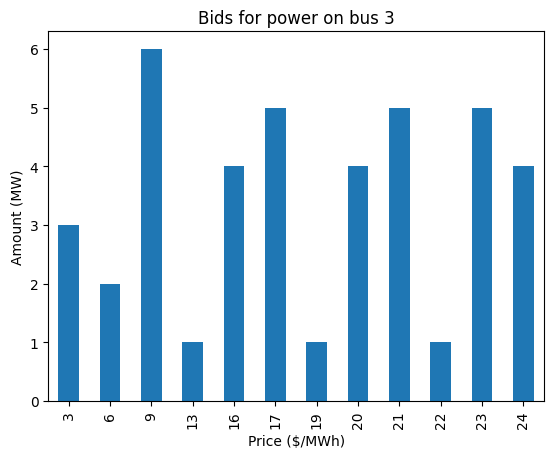

In [8]:
bid_bus = [node for node in load_node if node not in generator_node][0]
bus_bids = bids[bids["bus"] == bid_bus]
bus_bids[[
    "price", "amount"
    ]].groupby("price").sum().reset_index().plot.bar(
        x="price",
        y="amount",
        title=f"Bids for power on bus {bid_bus}",
        xlabel="Price ($/MWh)",
        ylabel="Amount (MW)",
        legend=False
        )

# Transmission Constraints

In [9]:
G = generator_cost.shape[0]
D = bids.shape[0]
bid_bus = bids["bus"].to_numpy()
bid_amount = bids["amount"].to_numpy()
bid_price = bids["price"].to_numpy()

thermal_flow_lim = branches_df['Lim MVA A'].to_numpy()

power_balance_cons_vec = np.concatenate((np.ones((G, 1)), -1*np.ones((D, 1)))).T

## Injection Mapping

In [10]:
gen_node_indices = [bus_to_idx[bus] for bus in generator_node]
bid_bus_indices = [bus_to_idx[bus] for bus in bid_bus]

In [11]:
gen_node_map = np.zeros((buses_df.shape[0], G))
gen_node_map[gen_node_indices, np.arange(G)] = 1
load_node_map = np.zeros((buses_df.shape[0], D))
load_node_map[bid_bus_indices, np.arange(D)] = -1

injection_map = np.hstack((gen_node_map, load_node_map))

## Shift Factor to Thermal Flow Mapping

In [12]:
# Create a mapping from line to thermal flow lim
thermal_flow_mapping = branches_df[['From Number', 'To Number', 'Lim MVA A']]
sf_no_contingency = ptdf_df.iloc[:, 5:]

# match the thermal flow lim to the shift factor values
sf_names = sf_no_contingency.columns.values
thermal_flow_lim = np.zeros((sf_names.shape[0]))
for (ind, line) in enumerate(sf_names):
    line_string = line.split(' ')
    from_no = int(line_string[0])
    to_no = int(line_string[4])
    thermal_flow_lim[ind] = thermal_flow_mapping.query('`From Number` == @from_no and `To Number` == @to_no')['Lim MVA A'].iloc[0]

sf_no_contingency = sf_no_contingency.to_numpy().T

In [13]:
sf_contingency = sf_contingencies_df.iloc[:, 5:]

# match the thermal flow lim to the shift factor contingency values
contingency_names = sf_contingency.columns.values
thermal_flow_lim_contingencies = np.zeros((contingency_names.shape[0]))
for (ind, contingency) in enumerate(contingency_names):
    line_string = contingency.split('_')[2]
    from_no = int(line_string.split('-')[0])
    to_no = int(line_string.split('-')[1])
    thermal_flow_lim_contingencies[ind] = thermal_flow_mapping.query('`From Number` == @from_no and `To Number` == @to_no')['Lim MVA A'].iloc[0]

sf_contingency = sf_contingency.to_numpy().T

In [14]:
base_case_trans_cons_mat = sf_no_contingency @ injection_map
contingency_trans_cons_mat = sf_contingency @ injection_map

## Model Set-up

In [15]:
lp_model = gp.Model()
generators = lp_model.addMVar(G, name='generators')
loads = lp_model.addMVar(D, name='bid_clearance', lb=0.0, ub=bid_amount)

# We maximize served demand - cost of generation
x_dispatch = gp.hstack((generators, loads))
obj_c = np.hstack((-generator_cost, bid_price))
lp_model.setMObjective(Q=None, c=obj_c, xc=x_dispatch, constant=0, sense=GRB.MAXIMIZE)

power_balance_cons = lp_model.addMConstr(power_balance_cons_vec, x_dispatch, '=', [0], 'power balance')
generator_min_cons = lp_model.addMConstr(np.eye(G), generators, '>=', generator_min, 'min generator capacity')
generator_max_cons = lp_model.addMConstr(np.eye(G), generators, '<=', generator_max, 'max generator capacity')
load_limits_cons = lp_model.addMConstr(np.eye(D), loads, '<=', bid_amount, 'max load bid')
base_case_cons_min = lp_model.addMConstr(base_case_trans_cons_mat, x_dispatch, '>=', -1 * thermal_flow_lim, 'Base Case Transmission Min')
base_case_cons_max = lp_model.addMConstr(base_case_trans_cons_mat, x_dispatch, '<=', thermal_flow_lim, 'Base Case Transmission Max')
contingency_cons_min = lp_model.addMConstr(contingency_trans_cons_mat, x_dispatch, '>=', -1 * thermal_flow_lim_contingencies, 'Contingency Transmission Min')
contingency_cons_max = lp_model.addMConstr(contingency_trans_cons_mat, x_dispatch, '<=', thermal_flow_lim_contingencies, 'Contingency Transmission Max')

lp_model.update()
lp_model.optimize()

Set parameter Username
Set parameter LicenseID to value 2762801
Academic license - for non-commercial use only - expires 2027-01-10
Set parameter LicenseID to value 2762801
Academic license - for non-commercial use only - expires 2027-01-10
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M1 Max
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 3092 rows, 192 columns and 512765 nonzeros (Max)
Model fingerprint: 0x4a4ef674
Model has 192 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-04, 1e+00]
  Objective range  [2e+00, 2e+01]
  Bounds range     [1e+00, 1e+01]
  RHS range        [1e+00, 2e+03]

Presolve removed 2236 rows and 42 columns
Presolve time: 0.04s
Presolved: 856 rows, 232 columns, 125301 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.5604326e+04   5.674264e+04   0.000000e+00      0s
       2    9.6133286

## Solutions

In [16]:
load_results = bids.copy().sort_values(by=["bus", "price", "amount"], ignore_index=True, ascending=[True, False, False])
load_results["cleared"] = loads.X
load_results

,bus,price,amount,cleared
0,3,24,4.0,4.0
1,3,23,5.0,5.0
2,3,22,1.0,1.0
3,3,21,5.0,5.0
4,3,20,4.0,4.0
...,...,...,...,...
176,24,4,9.0,0.0
177,24,4,5.0,0.0
178,24,4,2.0,0.0
179,24,3,5.0,0.0


In [17]:
# cleared at each bus
load_results.groupby("bus")["cleared"].sum().reset_index()

,bus,cleared
0,3,36.000000
1,4,38.761229
2,5,34.000000
3,6,56.000000
4,8,36.000000
5,9,46.000000
6,10,50.000000
7,11,79.000000
8,12,53.000000
9,17,67.000000


In [18]:
# gen results
gen_results = pd.DataFrame(
    {
        "generator": np.arange(1, G + 1),
        "bus": generator_node,
        "cleared": generators.X,
        "cost": generator_cost,
        "Pmin": generator_min,
        "Pmax": generator_max
    }   
)
gen_results.head()

,generator,bus,cleared,cost,Pmin,Pmax
0,1,1,30.0,14,30.0,890.0
1,2,2,350.0,-8,0.0,1010.0
2,3,7,0.0,9,0.0,1150.0
3,4,13,10.0,13,10.0,1450.0
4,5,14,30.0,14,30.0,1090.0


In [19]:
load_results.groupby("bus")["cleared"].sum().reset_index(drop=True)

0     36.000000
1     38.761229
2     34.000000
3     56.000000
4     36.000000
5     46.000000
6     50.000000
7     79.000000
8     53.000000
9     67.000000
10    52.000000
11    52.000000
12    53.000000
Name: cleared, dtype: float64

In [20]:
lambda_energy = power_balance_cons.Pi[0]
mu_base_max = base_case_cons_max.Pi
mu_base_min = base_case_cons_min.Pi
mu_cont_max = contingency_cons_max.Pi
mu_cont_min = contingency_cons_min.Pi
ptdf_bus = ptdf_df.iloc[:, 5:].to_numpy()   # rows = buses, cols = lines
lmp_base = lambda_energy + ptdf_bus @ (mu_base_max + mu_base_min)
sf_bus_cont = sf_contingencies_df.iloc[:, 5:].to_numpy()   # rows = buses, cols = monitored-line/contingency pairs
lmp_sc = (lmp_base + sf_bus_cont @ (mu_cont_max + mu_cont_min))

lmp_df = pd.DataFrame({
    "bus": buses_df["Number"],
    "LMP": lmp_sc,
}).merge(
    load_results.groupby("bus")["cleared"].sum().reset_index().rename(columns={"cleared": "Load Cleared"}), on="bus", how="left"
    ).merge(
        gen_results, on="bus", how="left"
        ).drop(
            columns=["generator"]
            ).rename(
                columns={"cleared": "Gen Cleared", 
                         "cost": "Gen Cost", 
                         "Pmin": "Gen Pmin", 
                         "Pmax": "Gen Pmax"}
                )
lmp_df

,bus,LMP,Load Cleared,Gen Cleared,Gen Cost,Gen Pmin,Gen Pmax
0,1,-6.136722,NaN,30.000000,14.0,30.0,890.0
1,2,8.000000,NaN,350.000000,-8.0,0.0,1010.0
2,3,-7.319937,36.000000,NaN,NaN,NaN,NaN
3,4,-14.000000,38.761229,NaN,NaN,NaN,NaN
4,5,-5.662333,34.000000,NaN,NaN,NaN,NaN
5,6,-3.395193,56.000000,NaN,NaN,NaN,NaN
6,7,-6.715918,NaN,0.000000,9.0,0.0,1150.0
7,8,-6.715918,36.000000,NaN,NaN,NaN,NaN
8,9,-8.268716,46.000000,NaN,NaN,NaN,NaN
9,10,-5.165879,50.000000,NaN,NaN,NaN,NaN


In [21]:
dispatch_vector = x_dispatch.X

base_case_flow = base_case_trans_cons_mat @ dispatch_vector

base_case_flow_df = pd.DataFrame({
    "branch": sf_names,
    "flow_mw": base_case_flow,
    "limit_mva": thermal_flow_lim,
})

base_case_flow_df["abs_flow_mw"] = base_case_flow_df["flow_mw"].abs()
base_case_flow_df["pct_of_limit"] = 100 * base_case_flow_df["abs_flow_mw"] / base_case_flow_df["limit_mva"]

base_case_flow_df.sort_values("abs_flow_mw", ascending=False).reset_index(drop=True)


,branch,flow_mw,limit_mva,abs_flow_mw,pct_of_limit
0,1 TO 2 CKT 1,-162.972557,175.0,162.972557,93.127175
1,1 TO 5 CKT 1,120.608009,175.0,120.608009,68.918862
2,2 TO 4 CKT 1,98.432818,175.0,98.432818,56.247325
3,2 TO 6 CKT 1,88.587325,175.0,88.587325,50.621329
4,17 TO 18 CKT 1,-88.117821,500.0,88.117821,17.623564
5,5 TO 10 CKT 1,86.608009,175.0,86.608009,49.490291
6,16 TO 19 CKT 1,78.307047,500.0,78.307047,15.661409
7,3 TO 1 CKT 1,-72.368447,175.0,72.368447,41.353398
8,4 TO 9 CKT 1,59.671589,175.0,59.671589,34.098051
9,15 TO 24 CKT 1,45.899630,500.0,45.899630,9.179926


In [22]:
spec = ['24', 'bus']
output_dir = Path('./results') / '-'.join(spec)
spec = ''.join(spec) # nice

lmp_df.to_csv(output_dir / f"lmp_results-{spec}.csv", index=False)
base_case_flow_df.sort_values("abs_flow_mw", ascending=False).reset_index(drop=True).to_csv(
    output_dir / f"base_case_flow_results-{spec}.csv", index=False
)
load_results.to_csv(output_dir / f"load_results-{spec}.csv", index=False)
branches_df.to_csv(output_dir / f"branches-actual-{spec}.csv", index=False)

In [23]:
lp_model.write((output_dir / f"model-{spec}.lp").as_posix())